In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "../data/raw/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("ShopSense Analytics")
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

ShopSense Analytics
Dataset loaded successfully!
Rows: 9994
Columns: 21


In [2]:
print("TEST - Jupyter is working")

TEST - Jupyter is working


In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-

In [8]:
# Convert date columns to proper datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check updated data types
print("\nData types:")
print(df[["Order Date", "Ship Date"]].dtypes)

Duplicate rows: 0

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data types:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [9]:
# Basic Business Overview

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print("===== ShopSense Business Overview =====")
print("Total Sales      :", round(total_sales, 2))
print("Total Profit     :", round(total_profit, 2))
print("Total Quantity   :", total_quantity)
print("Total Orders     :", total_orders)
print("Total Customers  :", total_customers)

===== ShopSense Business Overview =====
Total Sales      : 2297200.86
Total Profit     : 286397.02
Total Quantity   : 37873
Total Orders     : 5009
Total Customers  : 793


In [10]:
# Category Performance Analysis

category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values("Sales", ascending=False)

category_analysis["Profit Margin %"] = (
    category_analysis["Profit"] / category_analysis["Sales"] * 100
).round(2)

category_analysis

,Sales,Profit,Quantity,Profit Margin %
Category,,,,
Technology,836154.0330,145454.9481,6939,17.40
Furniture,741999.7953,18451.2728,8028,2.49
Office Supplies,719047.0320,122490.8008,22906,17.04


In [11]:
# Monthly Sales Trend

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Month"] = monthly_sales["Order Date"].dt.strftime("%b %Y")

monthly_sales

,Order Date,Sales,Month
0,2014-01-31,14236.8950,Jan 2014
1,2014-02-28,4519.8920,Feb 2014
2,2014-03-31,55691.0090,Mar 2014
3,2014-04-30,28295.3450,Apr 2014
4,2014-05-31,23648.2870,May 2014
5,2014-06-30,34595.1276,Jun 2014
6,2014-07-31,33946.3930,Jul 2014
7,2014-08-31,27909.4685,Aug 2014
8,2014-09-30,81777.3508,Sep 2014
9,2014-10-31,31453.3930,Oct 2014


In [12]:
# Regional Performance Analysis

region_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).sort_values("Sales", ascending=False)

region_analysis["Profit Margin %"] = (
    region_analysis["Profit"] / region_analysis["Sales"] * 100
).round(2)

region_analysis

,Sales,Profit,Orders,Profit Margin %
Region,,,,
West,725457.8245,108418.4489,1611,14.94
East,678781.2400,91522.7800,1401,13.48
Central,501239.8908,39706.3625,1175,7.92
South,391721.9050,46749.4303,822,11.93


In [13]:
# Top 10 Products by Sales

top_products = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .sort_values("Sales", ascending=False)
      .head(10)
)

top_products

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


In [14]:
# Loss-Making Products

loss_products = (
    df.groupby("Product Name")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum")
      )
      .query("Profit < 0")
      .sort_values("Profit")
)

loss_products.head(10)

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [15]:
# Discount vs Profit Analysis

discount_analysis = (
    df.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

discount_analysis["Profit Margin %"] = (
    discount_analysis["Profit"] / discount_analysis["Sales"] * 100
).round(2)

discount_analysis

,Discount,Sales,Profit,Orders,Profit Margin %
0,0.00,1.087908e+06,320987.6032,2644,29.51
1,0.10,5.436935e+04,9029.1770,89,16.61
2,0.15,2.755852e+04,1418.9915,51,5.15
3,0.20,7.645944e+05,90337.3060,2407,11.82
4,0.30,1.032267e+05,-10369.2774,211,-10.05
5,0.32,1.449346e+04,-2391.1377,27,-16.50
6,0.40,1.164178e+05,-23057.0504,185,-19.81
7,0.45,5.484974e+03,-2493.1111,10,-45.45
8,0.50,5.891854e+04,-20506.4281,64,-34.80
9,0.60,6.644700e+03,-5944.6552,127,-89.46


In [16]:
# Customer Segmentation Analysis

customer_analysis = (
    df.groupby("Customer ID")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

customer_analysis["Profit Margin %"] = (
    customer_analysis["Profit"] / customer_analysis["Sales"] * 100
).round(2)

customer_analysis.head()

,Customer ID,Sales,Profit,Orders,Quantity,Profit Margin %
0,AA-10315,5563.560,-362.8825,5,30,-6.52
1,AA-10375,1056.390,277.3824,9,41,26.26
2,AA-10480,1790.512,435.8274,4,36,24.34
3,AA-10645,5086.935,857.8033,6,64,16.86
4,AB-10015,886.156,129.3465,3,13,14.60


In [17]:
# Customer Value Segmentation

sales_75 = customer_analysis["Sales"].quantile(0.75)
sales_25 = customer_analysis["Sales"].quantile(0.25)

customer_analysis["Customer Segment"] = np.where(
    customer_analysis["Sales"] >= sales_75,
    "High Value",
    np.where(
        customer_analysis["Sales"] <= sales_25,
        "Low Value",
        "Regular Value"
    )
)

customer_analysis["Customer Segment"].value_counts()

Customer Segment
Regular Value    395
High Value       199
Low Value        199
Name: count, dtype: int64

In [18]:
# Segment Performance Analysis

segment_analysis = (
    customer_analysis.groupby("Customer Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Orders", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

segment_analysis["Profit Margin %"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"] * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    "Sales", ascending=False
)

segment_analysis

,Customer Segment,Customers,Sales,Profit,Orders,Quantity,Profit Margin %
0,High Value,199,1.266451e+06,187855.2010,1571,13633,14.83
2,Regular Value,395,9.043144e+05,84847.3155,2593,19097,9.38
1,Low Value,199,1.264357e+05,13694.5052,845,5143,10.83


In [19]:
# ShopSense Business Recommendations

recommendations = []

# Category recommendation
lowest_margin_category = category_analysis["Profit Margin %"].idxmin()
lowest_margin_value = category_analysis.loc[
    lowest_margin_category, "Profit Margin %"
]

recommendations.append(
    f"Review {lowest_margin_category} category profitability. "
    f"Its profit margin is only {lowest_margin_value:.2f}%."
)

# Discount recommendation
high_discount_loss = discount_analysis[
    (discount_analysis["Discount"] >= 0.30) &
    (discount_analysis["Profit"] < 0)
]

if not high_discount_loss.empty:
    recommendations.append(
        "High discounts are creating profit risk. "
        "Discount levels of 30% or above are associated with negative profit."
    )

# Loss-making products
loss_count = len(loss_products)

recommendations.append(
    f"{loss_count} products are currently generating negative profit. "
    "These products should be reviewed for pricing, discounting, or cost issues."
)

# Customer recommendation
recommendations.append(
    "Prioritize retention of High Value customers and use "
    "upselling/cross-selling strategies for Regular Value customers."
)

print("===== ShopSense Business Recommendations =====\n")

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

===== ShopSense Business Recommendations =====

1. Review Furniture category profitability. Its profit margin is only 2.49%.
2. High discounts are creating profit risk. Discount levels of 30% or above are associated with negative profit.
3. 301 products are currently generating negative profit. These products should be reviewed for pricing, discounting, or cost issues.
4. Prioritize retention of High Value customers and use upselling/cross-selling strategies for Regular Value customers.


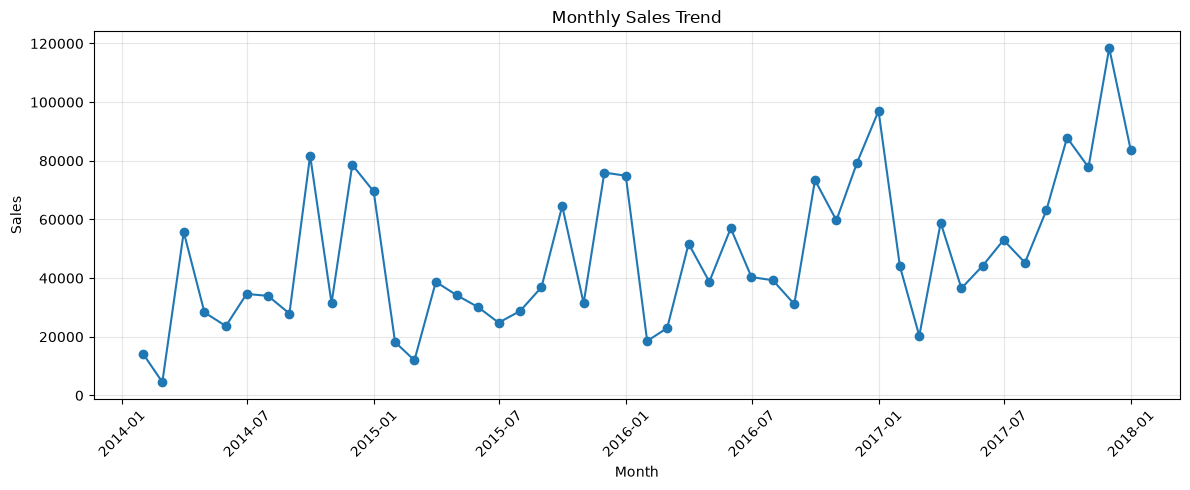

In [20]:
# Monthly Sales Trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

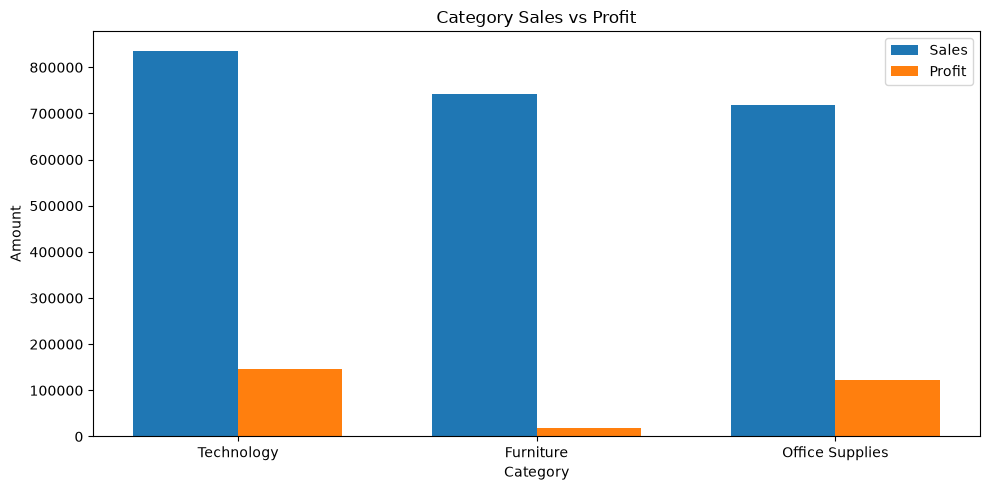

In [21]:
# Category Sales vs Profit

x = np.arange(len(category_analysis))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    category_analysis["Sales"],
    width,
    label="Sales"
)

plt.bar(
    x + width/2,
    category_analysis["Profit"],
    width,
    label="Profit"
)

plt.xticks(x, category_analysis.index)
plt.xlabel("Category")
plt.ylabel("Amount")
plt.title("Category Sales vs Profit")
plt.legend()

plt.tight_layout()
plt.show()

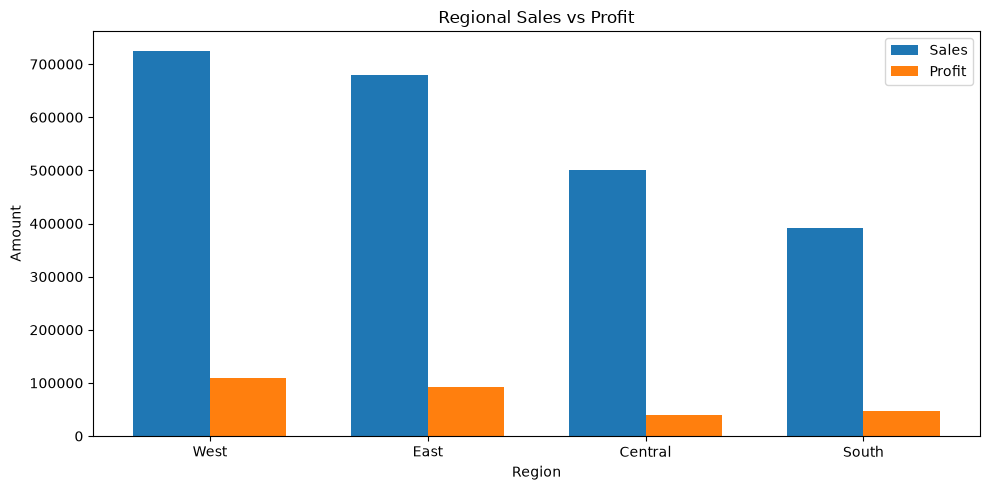

In [22]:
# Regional Sales vs Profit

x = np.arange(len(region_analysis))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    region_analysis["Sales"],
    width,
    label="Sales"
)

plt.bar(
    x + width/2,
    region_analysis["Profit"],
    width,
    label="Profit"
)

plt.xticks(x, region_analysis.index)
plt.xlabel("Region")
plt.ylabel("Amount")
plt.title("Regional Sales vs Profit")
plt.legend()

plt.tight_layout()
plt.show()

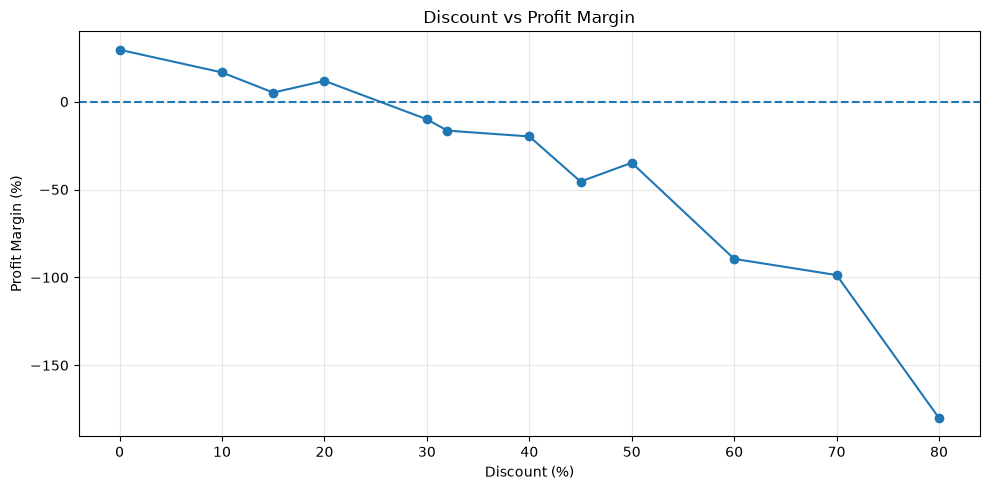

In [23]:
# Discount vs Profit Margin

plt.figure(figsize=(10, 5))

plt.plot(
    discount_analysis["Discount"] * 100,
    discount_analysis["Profit Margin %"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.title("Discount vs Profit Margin")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

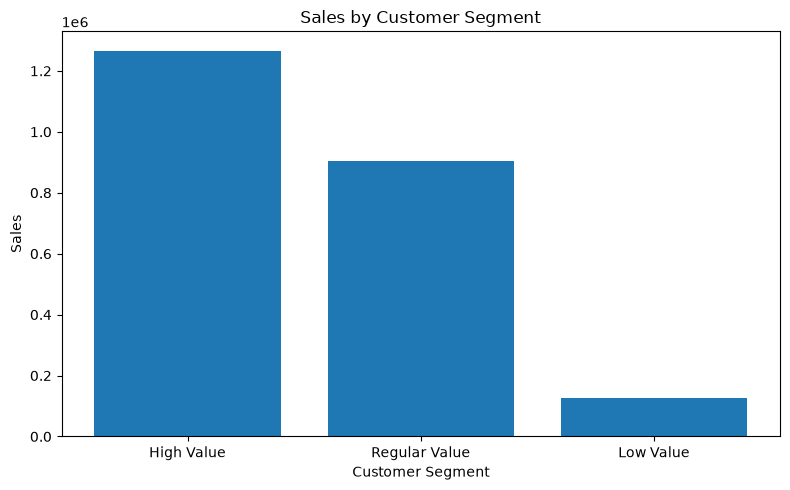

In [24]:
# Customer Segment Analysis

plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis["Customer Segment"],
    segment_analysis["Sales"]
)

plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.title("Sales by Customer Segment")

plt.tight_layout()
plt.show()

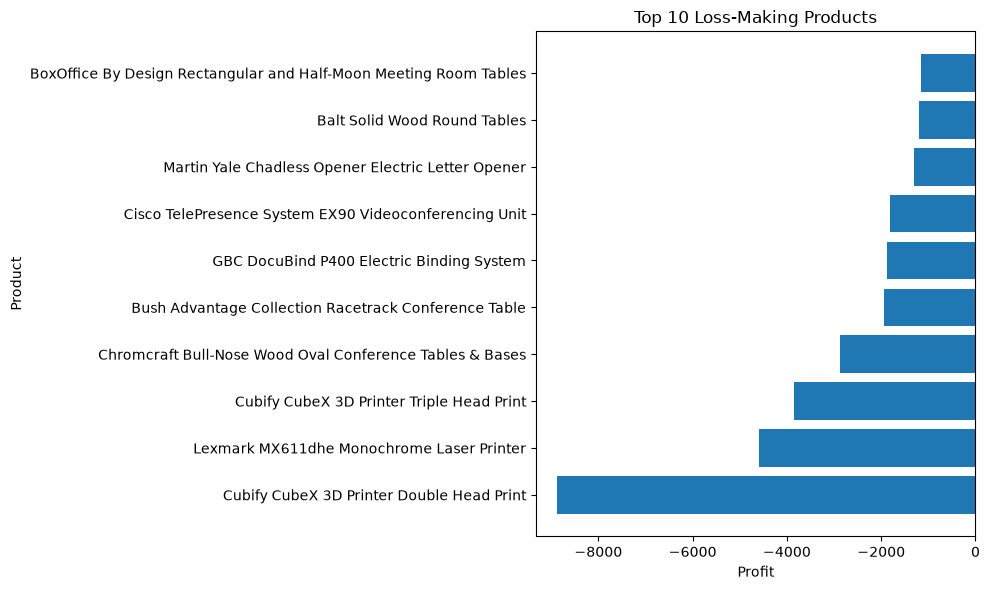

In [25]:
# Top Loss-Making Products

top_loss_products = loss_products.head(10).sort_values("Profit")

plt.figure(figsize=(10, 6))

plt.barh(
    top_loss_products.index,
    top_loss_products["Profit"]
)

plt.xlabel("Profit")
plt.ylabel("Product")
plt.title("Top 10 Loss-Making Products")

plt.tight_layout()
plt.show()

In [ ]:
s